In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:

df = pd.read_csv('../data/outlier_treated_data/gurgaon_properties_outlier_treated.csv')

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flats,breez global hill view,sohna road,0.35,6318.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,2,14.0,West,New Property,NaN,NaN,554.125572,0,0,0,0,0,1,53,277.0
1,flats,tulip violet,sector 69,1.65,8871.0,1860.0,Built Up area: 1578 (146.6 sq.m.),3,3,2,1.0,NaN,Relatively New,NaN,1578.0,NaN,0,0,0,0,0,0,69,620.0
2,house,suncity township,sector 54,25.00,31110.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,1,0,2009.0
3,flats,shree vardhman victoria,sector 70,1.75,8974.0,1950.0,Built Up area: 1950 (181.16 sq.m.),3,5,0,0.0,NaN,Undefined,NaN,1950.0,NaN,0,0,0,0,0,1,47,650.0
4,flats,adani aangan galleria,sector 89,0.25,5000.0,500.0,Super Built up area 500(46.45 sq.m.)Built Up a...,1,1,1,6.0,NaN,New Property,500.0,430.0,410.000000,0,0,0,0,0,1,74,500.0


In [7]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

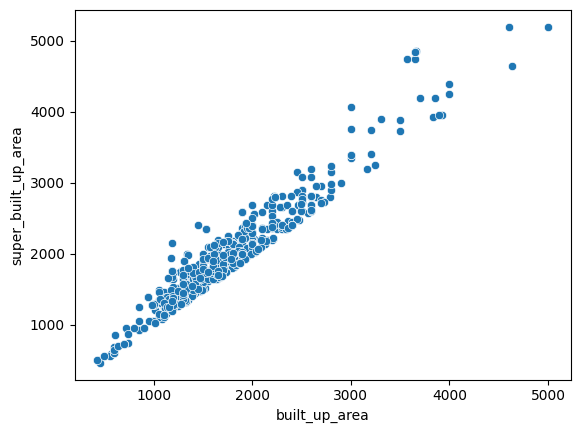

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

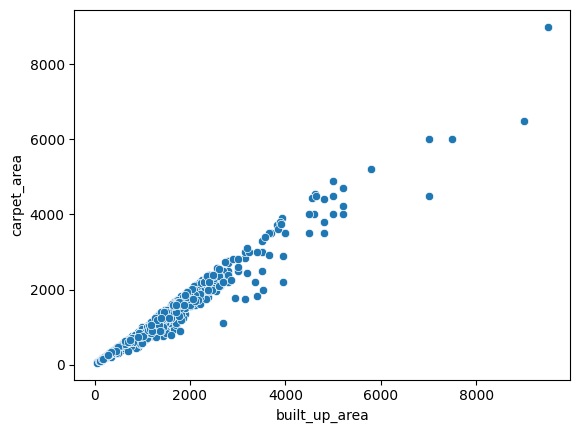

In [10]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [13]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).value_counts()

False    3555
Name: count, dtype: int64

In [14]:
#all three values are present
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [15]:
all_present_df.shape

(531, 24)

In [16]:

super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [17]:

carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [18]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [19]:

# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [20]:

sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
10,flats,tulip violet,sector 69,1.90,9453.0,2010.0,Super Built up area 2010(186.74 sq.m.)Carpet a...,4,4,2,6.0,West,Relatively New,2010.0,NaN,1500.0,0,0,1,0,0,1,174,502.500000
11,flats,breez global heights,sohna road,0.25,7003.0,357.0,Super Built up area 414(38.46 sq.m.)Carpet are...,1,1,1,1.0,NaN,Relatively New,414.0,NaN,357.0,0,0,0,0,0,1,57,357.000000
14,flats,cghs vidya enclave,sector 56,1.70,10968.0,1550.0,Super Built up area 1600(148.64 sq.m.)Carpet a...,3,2,3,6.0,NaN,Old Property,1600.0,NaN,1550.0,0,0,1,0,0,1,101,516.666667
18,flats,indiabulls centrum park,sector 103,1.01,8080.0,1250.0,Super Built up area 1423(132.2 sq.m.)Carpet ar...,2,2,3,5.0,West,Relatively New,1423.0,NaN,1250.0,0,0,1,0,0,0,165,625.000000
19,flats,satya the hermitage,sector 103,1.12,5625.0,1991.0,Super Built up area 1991(184.97 sq.m.)Carpet a...,3,4,3+,9.0,NaN,New Property,1991.0,NaN,1500.0,0,1,0,0,0,1,49,663.666667


In [21]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [22]:
df.update(sbc_df)

In [23]:

df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [24]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [25]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
5,flats,emaar mgf palm hills,sector 77,1.64,8410.0,1950.0,Super Built up area 1950(181.16 sq.m.),4,3,3,9.0,South,Relatively New,1950.0,NaN,NaN,0,1,0,0,0,1,102,487.500000
9,flats,microtek greenburg,sector 86,1.65,8707.0,1895.0,Super Built up area 1895(176.05 sq.m.),3,4,3,8.0,North-West,Relatively New,1895.0,NaN,NaN,0,1,0,0,0,1,124,631.666667
12,flats,umang winter hills,sector 77,0.86,6408.0,1342.0,Super Built up area 1342(124.68 sq.m.),2,2,2,16.0,NaN,New Property,1342.0,NaN,NaN,0,0,0,0,0,0,79,671.000000
31,flats,ss the leaf,sector 85,2.10,7468.0,2812.0,Super Built up area 2812(261.24 sq.m.),4,5,3+,9.0,East,Relatively New,2812.0,NaN,NaN,0,0,0,0,0,0,67,703.000000
37,flats,ansal heights 86,sector 86,0.78,5735.0,1360.0,Super Built up area 1360(126.35 sq.m.),2,2,1,8.0,East,New Property,1360.0,NaN,NaN,0,0,0,0,0,1,67,680.000000


In [26]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round

In [27]:
df.update(sb_df)

In [28]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [29]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [30]:

c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flats,breez global hill view,sohna road,0.35,6318.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,2,14.0,West,New Property,NaN,NaN,554.125572,0,0,0,0,0,1,53,277.000000
7,flats,satya the hermitage,sector 103,0.93,6405.0,1452.0,Carpet area: 1452 (134.9 sq.m.),2,3,3,3.0,East,Relatively New,NaN,NaN,1452.000000,0,1,0,0,0,0,90,726.000000
20,flats,deepak minda,manesar,1.20,4528.0,2650.0,Carpet area: 2650 (246.19 sq.m.),3,3,3+,6.0,North-West,Moderately Old,NaN,NaN,2650.000000,0,1,0,0,0,1,7,883.333333
22,flats,gls arawali homes,sohna road,0.27,4688.0,576.0,Carpet area: 576 (53.51 sq.m.),2,2,2,1.0,East,New Property,NaN,NaN,576.000000,0,0,0,0,0,1,35,288.000000
24,flats,microtek greenburg,sector 86,1.30,15294.0,850.0,Carpet area: 850 (78.97 sq.m.),2,3,3,5.0,North-East,Relatively New,NaN,NaN,850.000000,1,0,0,0,0,0,45,425.000000


In [31]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet

In [32]:
df.update(c_df)

In [33]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

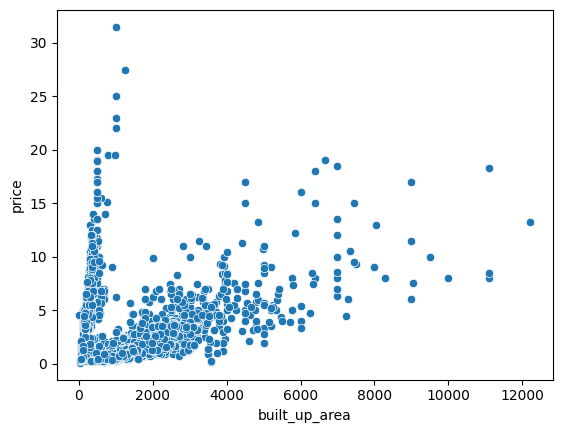

In [35]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [36]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [37]:
anamoly_df.sample(5)

,price,area,built_up_area
1289,2.80,2350.0,1798.0
2358,12.50,3060.0,410.0
1212,10.56,3240.0,360.0
1390,3.23,1202.0,1640.0
2881,10.00,3600.0,400.0


In [38]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [39]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

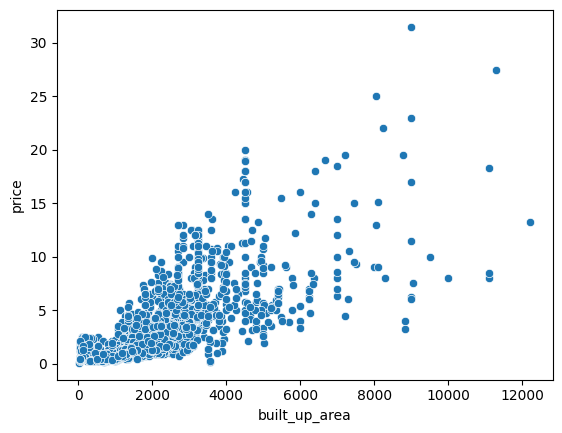

In [41]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [43]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [44]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flats,breez global hill view,sohna road,0.35,6318.0,2,2,2,14.0,West,New Property,616.0,0,0,0,0,0,1,53
1,flats,tulip violet,sector 69,1.65,8871.0,3,3,2,1.0,NaN,Relatively New,1578.0,0,0,0,0,0,0,69
2,house,suncity township,sector 54,25.00,31110.0,4,4,3+,2.0,North,Moderately Old,8036.0,0,0,0,0,0,1,0
3,flats,shree vardhman victoria,sector 70,1.75,8974.0,3,5,0,0.0,NaN,Undefined,1950.0,0,0,0,0,0,1,47
4,flats,adani aangan galleria,sector 89,0.25,5000.0,1,1,1,6.0,NaN,New Property,430.0,0,0,0,0,0,1,74


In [45]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floornum

In [46]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
113,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,0,0,0,0,0,2,0
346,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,9
702,house,dlf new town heights,sector 86,2.47,7719.0,4,4,3+,NaN,West,Moderately Old,2800.0,0,0,0,0,0,0,130
975,flats,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,1,0
990,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,1,21
1411,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,1,0
1532,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,1,28
1791,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,0,0,0,0,0,1,0
1896,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,60.0,0,0,0,0,0,1,9
1958,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,65.0,0,0,0,0,0,1,0


In [47]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [48]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\areeb\AppData\Local\Temp\ipykernel_9068\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [49]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### facing


<Axes: ylabel='count'>

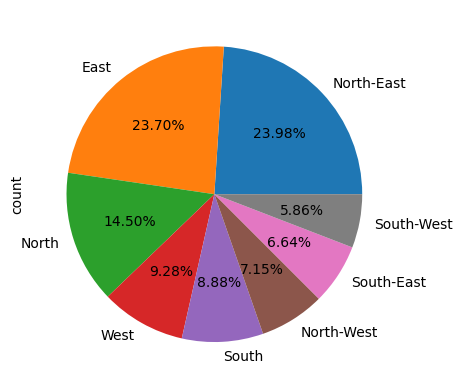

In [50]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [51]:
df.drop(columns=['facing'],inplace=True)

In [52]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [54]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2179,flats,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [55]:
df.drop(index=[2179],inplace=True)

In [56]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [57]:
df['agePossession'].value_counts()

agePossession
Relatively New        1605
New Property           557
Moderately Old         545
Undefined              423
Old Property           293
Under Construction     131
Name: count, dtype: int64

In [58]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,flats,shree vardhman victoria,sector 70,1.75,8974.0,3,5,0,0.0,Undefined,1950.0,0,0,0,0,0,1,47
28,flats,dlf the arbour,sector 63,7.90,20000.0,4,4,3+,34.0,Undefined,3950.0,0,0,0,0,0,1,61
40,house,ansal api esencia,sector 67,1.85,8222.0,3,3,3,1.0,Undefined,278.0,0,0,0,0,0,1,49
43,house,independent,sector 4,1.10,11111.0,3,4,1,2.0,Undefined,990.0,0,0,0,0,0,1,0
49,flats,signature global park,sohna road,0.55,6691.0,2,2,3,3.0,Undefined,913.0,0,0,0,0,0,1,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3508,flats,supertech hues,sector 68,0.93,8611.0,2,2,2,11.0,Undefined,1200.0,0,0,0,0,0,1,0
3532,flats,supertech araville,sector 79,0.90,6950.0,2,2,0,12.0,Undefined,1295.0,0,0,0,0,0,1,0
3540,house,independent,sector 36,0.75,6938.0,3,1,0,1.0,Undefined,1081.0,0,0,0,0,0,1,0
3550,house,bhim nagar society,sector 6,0.40,2500.0,4,2,2,1.0,Undefined,1600.0,0,0,0,0,0,1,0


In [59]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1782
New Property           634
Moderately Old         585
Old Property           330
Under Construction     133
Undefined               90
Name: count, dtype: int64

In [62]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [63]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [64]:
df['agePossession'].value_counts()

agePossession
Relatively New        1796
New Property           654
Moderately Old         592
Old Property           341
Under Construction     137
Undefined               34
Name: count, dtype: int64

In [65]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [66]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [67]:
df['agePossession'].value_counts()

agePossession
Relatively New        1807
New Property           654
Moderately Old         615
Old Property           341
Under Construction     137
Name: count, dtype: int64

In [68]:
import os
data_path=os.path.join('..','data','imputed_data')
os.makedirs(data_path)
df.to_csv(os.path.join(data_path,'gurgaon_properties_missing_value_imputation.csv'),index=False)